# FairDerm Results Analysis (Multi-Seed)

This notebook analyzes and visualizes results from trained FairDerm models across **multiple seeds (42 and 123)**.

**Purpose:** Generate publication-ready figures with error bars (mean ± std).

**Models Compared:**
1. **Baseline** - Standard CE loss + uniform sampling
2. **Mixup** - CE loss + mixup augmentation (α=0.4)
3. **Reweighted** - Weighted CE loss + class-weighted sampling
4. **Focal Loss** - Focal Loss (γ=2) + uniform sampling
5. **Proposed** - CE loss + skin-tone-adaptive sampling + mixup

**Output:**
- Figures with error bars
- CSV tables with mean ± std
- JSON files with full metrics

## 1. Setup and Imports

In [1]:
# Mount Google Drive (for Colab)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Set style for publication-quality figures
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 12

# Paths
RESULTS_DIR = Path('/content/drive/MyDrive/thesis/results')
FIGURES_DIR = RESULTS_DIR / 'figures_multiseed'
FIGURES_DIR.mkdir(exist_ok=True)

# Multi-seed configuration
SEEDS = [42, 123]
MODELS = ['baseline', 'mixup', 'reweighted', 'focalloss', 'proposed']
MODEL_DISPLAY_NAMES = {
    'baseline': 'Baseline',
    'mixup': 'Mixup',
    'reweighted': 'Reweighted',
    'focalloss': 'Focal Loss',
    'proposed': 'Proposed'
}

print(f"Results directory: {RESULTS_DIR}")
print(f"Figures will be saved to: {FIGURES_DIR}")

Results directory: /content/drive/MyDrive/thesis/results
Figures will be saved to: /content/drive/MyDrive/thesis/results/figures_multiseed


## 2. Load All Results (Both Seeds)

In [3]:
def load_model_results(model_name: str, seed: int) -> dict:
    """Load metrics.json for a specific model and seed."""
    metrics_path = RESULTS_DIR / f"{model_name}_seed{seed}" / "metrics.json"
    if metrics_path.exists():
        with open(metrics_path, 'r') as f:
            return json.load(f)
    return None

def load_training_history(model_name: str, seed: int) -> pd.DataFrame:
    """Load training_history.csv for a specific model and seed."""
    history_path = RESULTS_DIR / f"{model_name}_seed{seed}" / "training_history.csv"
    if history_path.exists():
        return pd.read_csv(history_path)
    return None

# Load all results: {model: {seed: metrics}}
all_results = {model: {} for model in MODELS}
all_histories = {model: {} for model in MODELS}

for model in MODELS:
    for seed in SEEDS:
        results = load_model_results(model, seed)
        history = load_training_history(model, seed)

        if results:
            all_results[model][seed] = results
            print(f"Loaded {model}_seed{seed}")
        else:
            print(f"Missing {model}_seed{seed}")

        if history is not None:
            all_histories[model][seed] = history

print(f"\nLoaded results for {len([m for m in MODELS if all_results[m]])} models")

Loaded baseline_seed42
Loaded baseline_seed123
Loaded mixup_seed42
Loaded mixup_seed123
Loaded reweighted_seed42
Loaded reweighted_seed123
Loaded focalloss_seed42
Loaded focalloss_seed123
Loaded proposed_seed42
Loaded proposed_seed123

Loaded results for 5 models


## 3. Aggregate Results (Mean ± Std)

In [4]:
def aggregate_model_metrics(model_results: dict) -> dict:
    """Aggregate metrics across seeds for a single model."""
    seeds_data = list(model_results.values())
    if len(seeds_data) == 0:
        return None

    result = {
        'overall': {},
        'fairness': {},
        'n_seeds': len(seeds_data)
    }

    # Overall metrics
    for key in ['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_weighted', 'roc_auc']:
        values = [s['overall'].get(key) for s in seeds_data if s['overall'].get(key) is not None]
        if values:
            result['overall'][key] = {
                'mean': np.mean(values),
                'std': np.std(values),
                'values': values
            }

    # Fairness metrics
    for key in ['equal_opportunity_gap', 'equalized_odds_gap', 'f1_gap']:
        values = [s['fairness'].get(key) for s in seeds_data if s['fairness'].get(key) is not None]
        if values:
            result['fairness'][key] = {
                'mean': np.mean(values),
                'std': np.std(values),
                'values': values
            }

    # Per-group TPR
    result['fairness']['tpr_per_group'] = {}
    for group in ['Light', 'Medium', 'Dark']:
        values = [s['fairness']['tpr_per_group'].get(group) for s in seeds_data
                  if s['fairness']['tpr_per_group'].get(group) is not None]
        if values:
            result['fairness']['tpr_per_group'][group] = {
                'mean': np.mean(values),
                'std': np.std(values),
                'values': values
            }

    # Per-group FPR
    result['fairness']['fpr_per_group'] = {}
    for group in ['Light', 'Medium', 'Dark']:
        values = [s['fairness']['fpr_per_group'].get(group) for s in seeds_data
                  if s['fairness']['fpr_per_group'].get(group) is not None]
        if values:
            result['fairness']['fpr_per_group'][group] = {
                'mean': np.mean(values),
                'std': np.std(values),
                'values': values
            }

    return result

# Aggregate all models
aggregated = {}
for model in MODELS:
    if all_results[model]:
        aggregated[model] = aggregate_model_metrics(all_results[model])
        print(f"Aggregated {model}: {aggregated[model]['n_seeds']} seeds")

print(f"\nAggregated {len(aggregated)} models")

Aggregated baseline: 2 seeds
Aggregated mixup: 2 seeds
Aggregated reweighted: 2 seeds
Aggregated focalloss: 2 seeds
Aggregated proposed: 2 seeds

Aggregated 5 models


## 4. Build Comparison DataFrames

In [5]:
def format_mean_std(mean, std):
    """Format as 'mean ± std'."""
    return f"{mean:.4f} ± {std:.4f}"

# Build DataFrames for plotting (with separate mean and std columns)
plot_data = []
for model in MODELS:
    if model in aggregated:
        m = aggregated[model]
        plot_data.append({
            'Model': MODEL_DISPLAY_NAMES[model],
            'Balanced Accuracy': m['overall']['balanced_accuracy']['mean'],
            'Balanced Accuracy Std': m['overall']['balanced_accuracy']['std'],
            'ROC-AUC': m['overall']['roc_auc']['mean'],
            'ROC-AUC Std': m['overall']['roc_auc']['std'],
            'F1 Macro': m['overall']['f1_macro']['mean'],
            'F1 Macro Std': m['overall']['f1_macro']['std'],
            'EO Gap': m['fairness']['equal_opportunity_gap']['mean'],
            'EO Gap Std': m['fairness']['equal_opportunity_gap']['std'],
            'Equalized Odds Gap': m['fairness']['equalized_odds_gap']['mean'],
            'Equalized Odds Gap Std': m['fairness']['equalized_odds_gap']['std'],
            'F1 Gap': m['fairness']['f1_gap']['mean'],
            'F1 Gap Std': m['fairness']['f1_gap']['std'],
            'TPR Light': m['fairness']['tpr_per_group']['Light']['mean'],
            'TPR Light Std': m['fairness']['tpr_per_group']['Light']['std'],
            'TPR Medium': m['fairness']['tpr_per_group']['Medium']['mean'],
            'TPR Medium Std': m['fairness']['tpr_per_group']['Medium']['std'],
            'TPR Dark': m['fairness']['tpr_per_group']['Dark']['mean'],
            'TPR Dark Std': m['fairness']['tpr_per_group']['Dark']['std'],
        })

plot_df = pd.DataFrame(plot_data).set_index('Model')

# Display table with mean ± std formatting
display_rows = []
for model in MODELS:
    if model in aggregated:
        m = aggregated[model]
        display_rows.append({
            'Model': MODEL_DISPLAY_NAMES[model],
            'Balanced Accuracy': format_mean_std(
                m['overall']['balanced_accuracy']['mean'],
                m['overall']['balanced_accuracy']['std']
            ),
            'ROC-AUC': format_mean_std(
                m['overall']['roc_auc']['mean'],
                m['overall']['roc_auc']['std']
            ),
            'EO Gap': format_mean_std(
                m['fairness']['equal_opportunity_gap']['mean'],
                m['fairness']['equal_opportunity_gap']['std']
            ),
            'TPR Dark': format_mean_std(
                m['fairness']['tpr_per_group']['Dark']['mean'],
                m['fairness']['tpr_per_group']['Dark']['std']
            ),
        })

display_df = pd.DataFrame(display_rows)
print("\nFitzpatrick17k Results (Mean ± Std over 2 seeds):")
print("=" * 90)
print(display_df.to_string(index=False))


Fitzpatrick17k Results (Mean ± Std over 2 seeds):
     Model Balanced Accuracy         ROC-AUC          EO Gap        TPR Dark
  Baseline   0.8272 ± 0.0094 0.9098 ± 0.0102 0.0918 ± 0.0049 0.7073 ± 0.0244
     Mixup   0.8561 ± 0.0095 0.9250 ± 0.0068 0.1005 ± 0.0089 0.7439 ± 0.0122
Reweighted   0.8261 ± 0.0072 0.9099 ± 0.0099 0.0835 ± 0.0007 0.7073 ± 0.0244
Focal Loss   0.8266 ± 0.0078 0.9066 ± 0.0095 0.0846 ± 0.0038 0.7195 ± 0.0122
  Proposed   0.8627 ± 0.0050 0.9302 ± 0.0039 0.0714 ± 0.0025 0.7805 ± 0.0000


## 5. Figure 1: Overall Performance with Error Bars

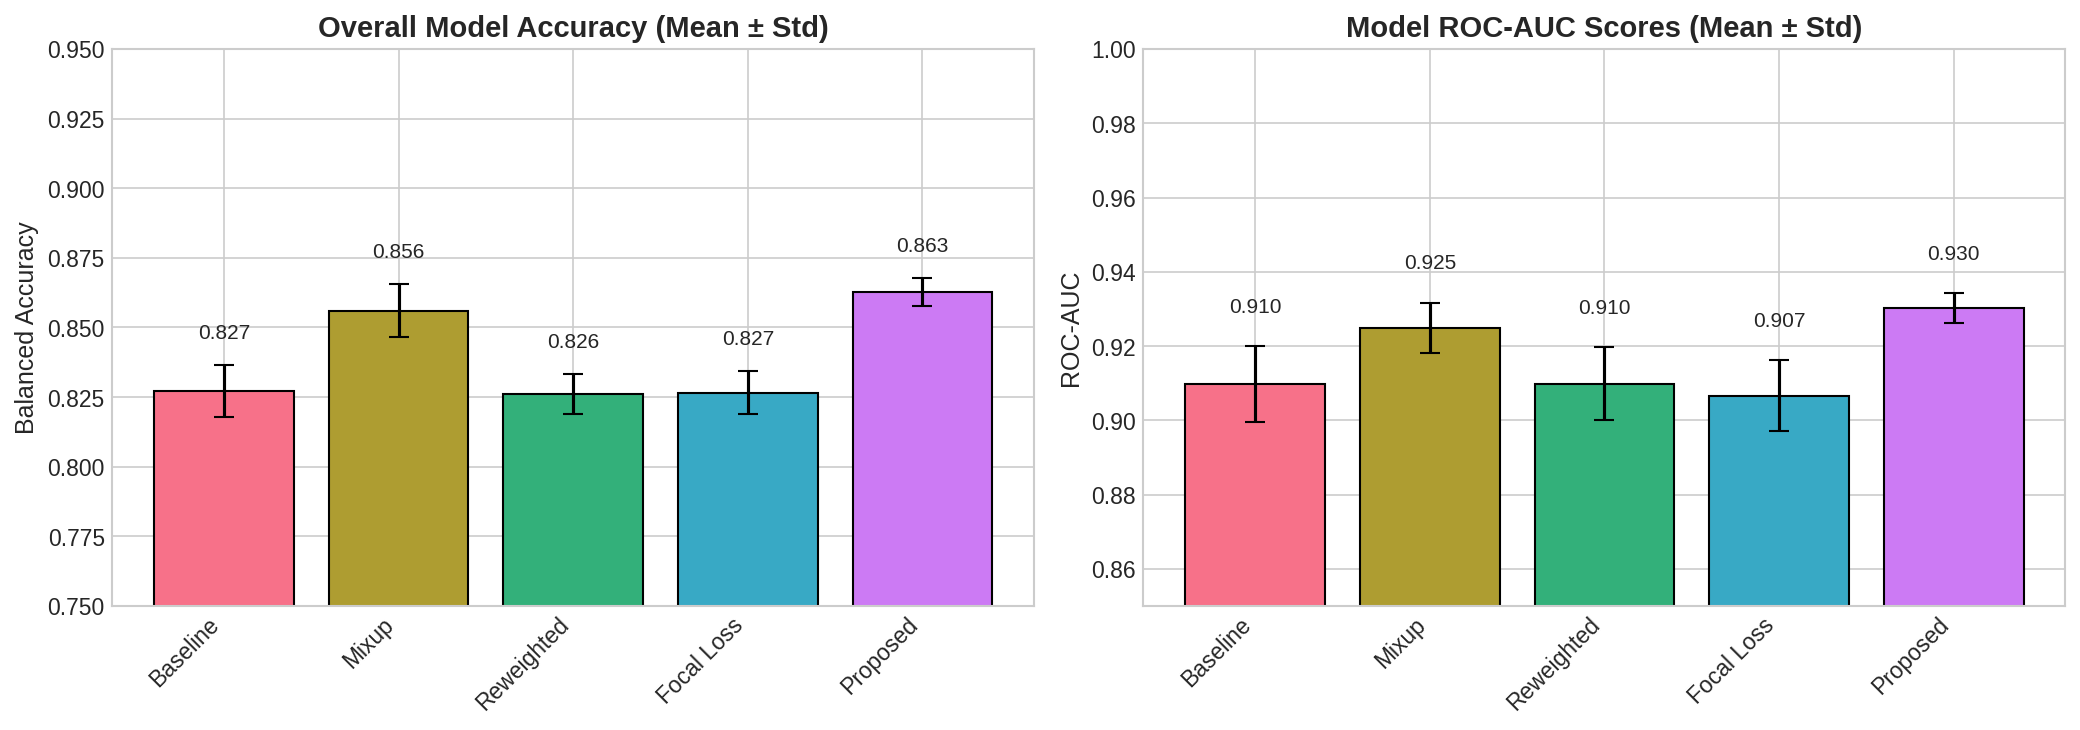

Saved: /content/drive/MyDrive/thesis/results/figures_multiseed/performance_comparison_multiseed.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = plot_df.index.tolist()
x = np.arange(len(models))
colors = sns.color_palette('husl', len(models))

# Balanced Accuracy with error bars
ax1 = axes[0]
bars1 = ax1.bar(x, plot_df['Balanced Accuracy'], yerr=plot_df['Balanced Accuracy Std'],
                color=colors, edgecolor='black', capsize=5, error_kw={'linewidth': 1.5})
ax1.set_ylabel('Balanced Accuracy', fontsize=12)
ax1.set_title('Overall Model Accuracy (Mean ± Std)', fontsize=14, fontweight='bold')
ax1.set_ylim(0.75, 0.95)
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=45, ha='right')

# Add value labels
for i, (bar, val, std) in enumerate(zip(bars1, plot_df['Balanced Accuracy'], plot_df['Balanced Accuracy Std'])):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.008,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)

# ROC-AUC with error bars
ax2 = axes[1]
bars2 = ax2.bar(x, plot_df['ROC-AUC'], yerr=plot_df['ROC-AUC Std'],
                color=colors, edgecolor='black', capsize=5, error_kw={'linewidth': 1.5})
ax2.set_ylabel('ROC-AUC', fontsize=12)
ax2.set_title('Model ROC-AUC Scores (Mean ± Std)', fontsize=14, fontweight='bold')
ax2.set_ylim(0.85, 1.0)
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=45, ha='right')

for i, (bar, val, std) in enumerate(zip(bars2, plot_df['ROC-AUC'], plot_df['ROC-AUC Std'])):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.008,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'performance_comparison_multiseed.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'performance_comparison_multiseed.png'}")

## 6. Figure 2: Fairness Gaps with Error Bars

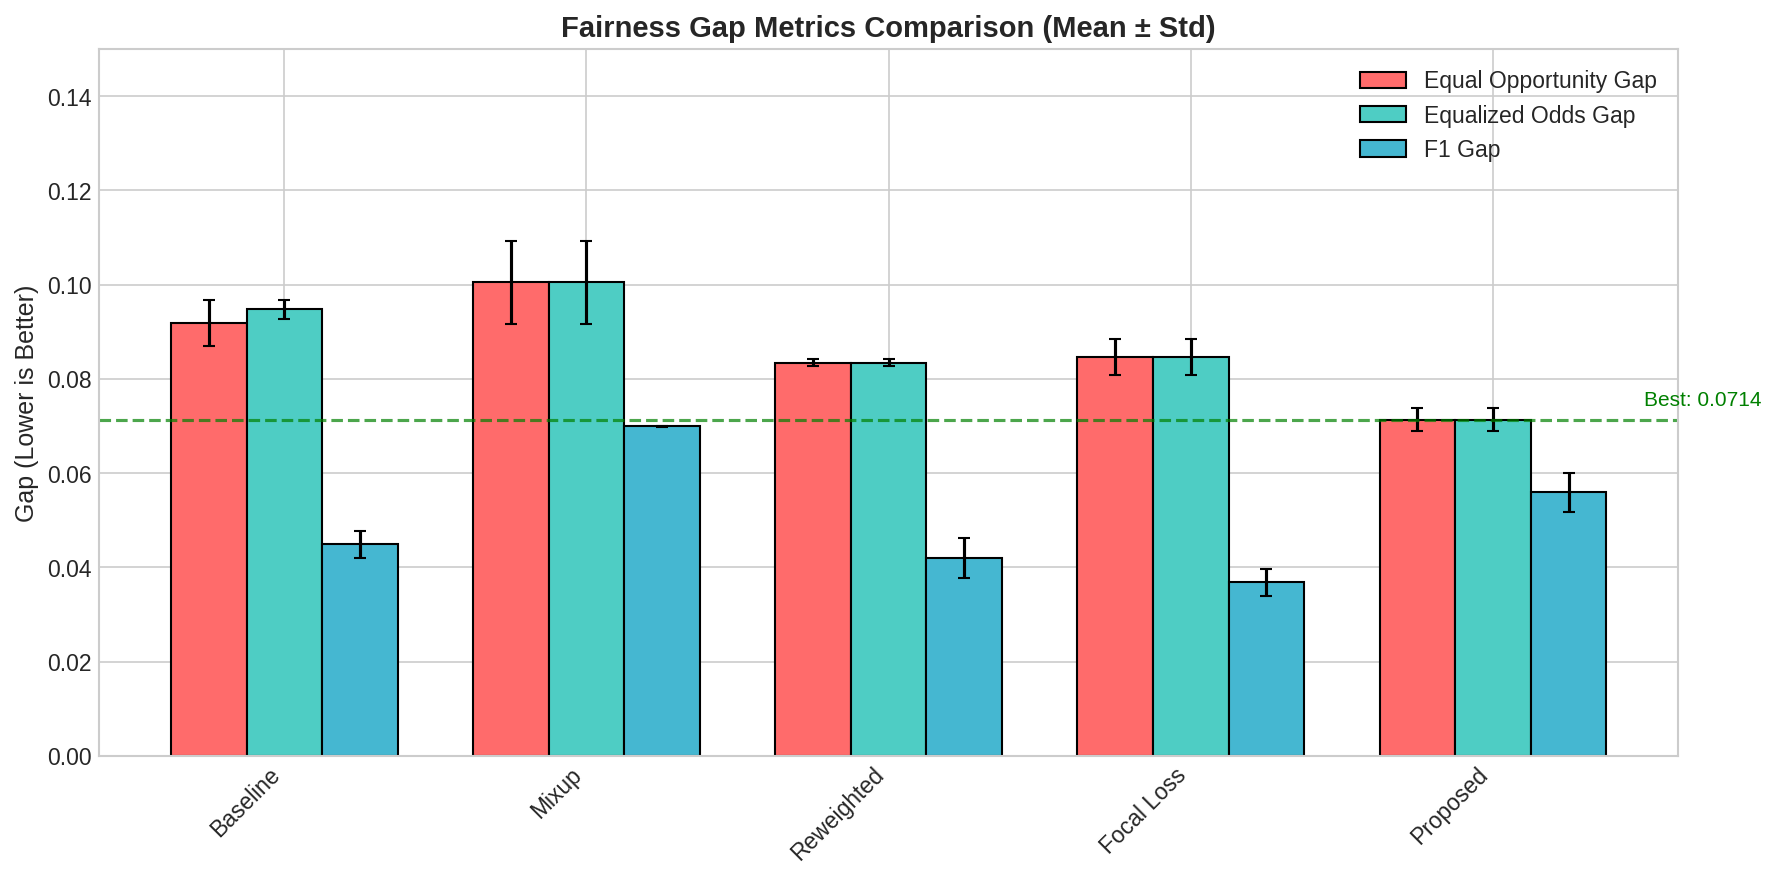

Saved: /content/drive/MyDrive/thesis/results/figures_multiseed/fairness_gaps_multiseed.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(models))
width = 0.25

# Three fairness metrics with error bars
bars1 = ax.bar(x - width, plot_df['EO Gap'], width, yerr=plot_df['EO Gap Std'],
               label='Equal Opportunity Gap', color='#FF6B6B', edgecolor='black', capsize=3)
bars2 = ax.bar(x, plot_df['Equalized Odds Gap'], width, yerr=plot_df['Equalized Odds Gap Std'],
               label='Equalized Odds Gap', color='#4ECDC4', edgecolor='black', capsize=3)
bars3 = ax.bar(x + width, plot_df['F1 Gap'], width, yerr=plot_df['F1 Gap Std'],
               label='F1 Gap', color='#45B7D1', edgecolor='black', capsize=3)

ax.set_ylabel('Gap (Lower is Better)', fontsize=12)
ax.set_title('Fairness Gap Metrics Comparison (Mean ± Std)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend(loc='upper right')
ax.set_ylim(0, 0.15)

# Add horizontal line at best EO Gap
best_eo = plot_df['EO Gap'].min()
ax.axhline(y=best_eo, color='green', linestyle='--', alpha=0.7, linewidth=1.5)
ax.text(len(models)-0.5, best_eo + 0.003, f'Best: {best_eo:.4f}', color='green', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fairness_gaps_multiseed.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'fairness_gaps_multiseed.png'}")

## 7. Figure 3: Per-Group TPR with Error Bars

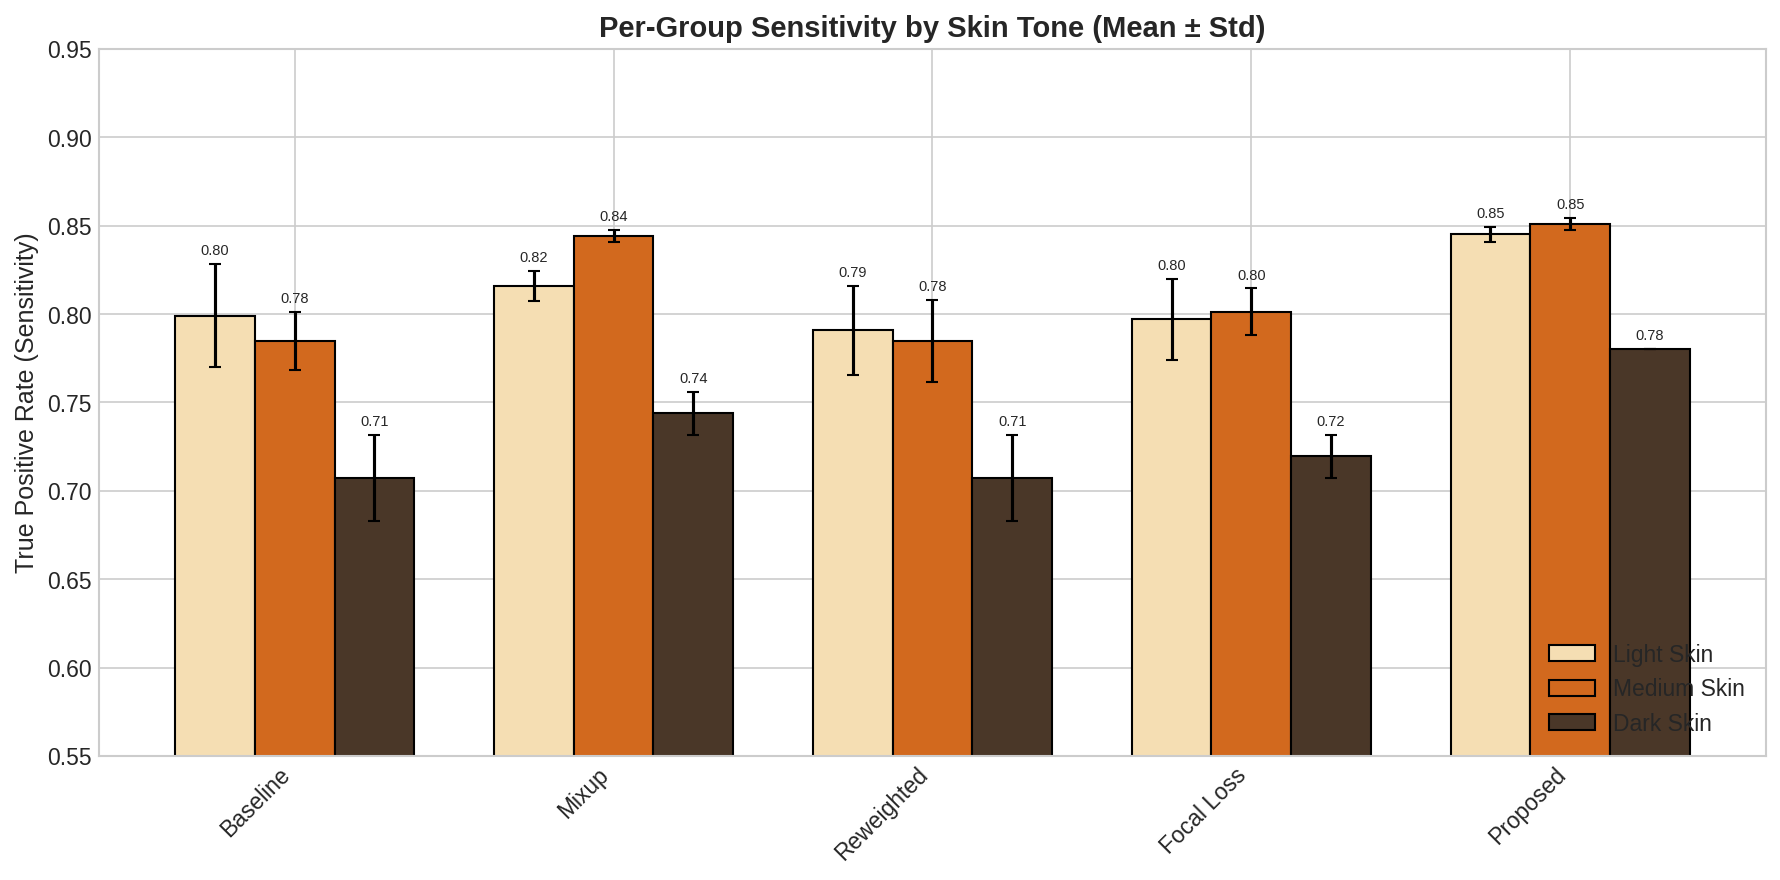

Saved: /content/drive/MyDrive/thesis/results/figures_multiseed/per_group_tpr_multiseed.png


In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(models))
width = 0.25

# Skin tone colors
skin_colors = ['#F5DEB3', '#D2691E', '#4A3728']  # Light, Medium, Dark

bars1 = ax.bar(x - width, plot_df['TPR Light'], width, yerr=plot_df['TPR Light Std'],
               label='Light Skin', color=skin_colors[0], edgecolor='black', capsize=3)
bars2 = ax.bar(x, plot_df['TPR Medium'], width, yerr=plot_df['TPR Medium Std'],
               label='Medium Skin', color=skin_colors[1], edgecolor='black', capsize=3)
bars3 = ax.bar(x + width, plot_df['TPR Dark'], width, yerr=plot_df['TPR Dark Std'],
               label='Dark Skin', color=skin_colors[2], edgecolor='black', capsize=3)

ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('Per-Group Sensitivity by Skin Tone (Mean ± Std)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0.55, 0.95)

# Add value labels
for bars, col, std_col in [(bars1, 'TPR Light', 'TPR Light Std'),
                            (bars2, 'TPR Medium', 'TPR Medium Std'),
                            (bars3, 'TPR Dark', 'TPR Dark Std')]:
    for bar, val, std in zip(bars, plot_df[col], plot_df[std_col]):
        ax.annotate(f'{val:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height() + std),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'per_group_tpr_multiseed.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'per_group_tpr_multiseed.png'}")

## 8. Figure 4: Accuracy-Fairness Tradeoff Scatter

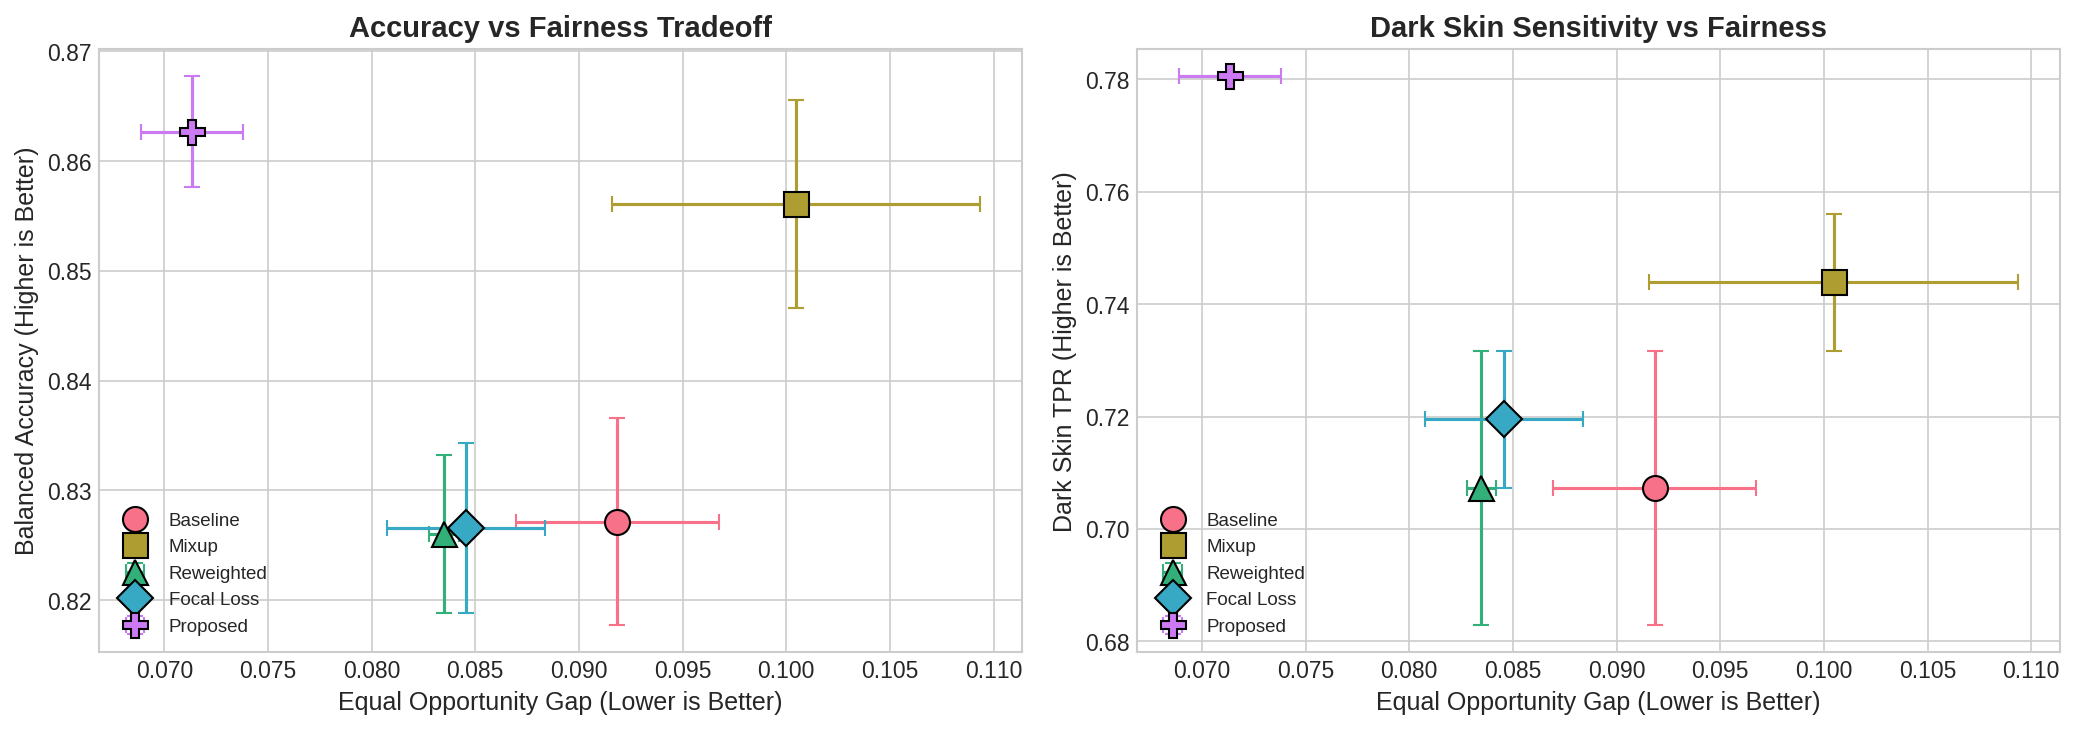

Saved: /content/drive/MyDrive/thesis/results/figures_multiseed/accuracy_fairness_tradeoff_multiseed.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = sns.color_palette('husl', len(models))
markers = ['o', 's', '^', 'D', 'P']

# Accuracy vs EO Gap with error bars
ax1 = axes[0]
for i, model in enumerate(models):
    row = plot_df.loc[model]
    ax1.errorbar(row['EO Gap'], row['Balanced Accuracy'],
                 xerr=row['EO Gap Std'], yerr=row['Balanced Accuracy Std'],
                 fmt=markers[i], markersize=12, color=colors[i],
                 label=model, capsize=4, capthick=1.5, elinewidth=1.5,
                 markeredgecolor='black', markeredgewidth=1)

ax1.set_xlabel('Equal Opportunity Gap (Lower is Better)', fontsize=12)
ax1.set_ylabel('Balanced Accuracy (Higher is Better)', fontsize=12)
ax1.set_title('Accuracy vs Fairness Tradeoff', fontsize=14, fontweight='bold')
ax1.legend(loc='lower left', fontsize=9)

# Add "best region" annotation
ax1.annotate('Best Region\n(High Acc, Low Gap)',
             xy=(0.065, 0.875), fontsize=10, color='green',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))

# Dark Skin TPR vs EO Gap
ax2 = axes[1]
for i, model in enumerate(models):
    row = plot_df.loc[model]
    ax2.errorbar(row['EO Gap'], row['TPR Dark'],
                 xerr=row['EO Gap Std'], yerr=row['TPR Dark Std'],
                 fmt=markers[i], markersize=12, color=colors[i],
                 label=model, capsize=4, capthick=1.5, elinewidth=1.5,
                 markeredgecolor='black', markeredgewidth=1)

ax2.set_xlabel('Equal Opportunity Gap (Lower is Better)', fontsize=12)
ax2.set_ylabel('Dark Skin TPR (Higher is Better)', fontsize=12)
ax2.set_title('Dark Skin Sensitivity vs Fairness', fontsize=14, fontweight='bold')
ax2.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'accuracy_fairness_tradeoff_multiseed.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'accuracy_fairness_tradeoff_multiseed.png'}")

## 9. Figure 5: Training History Comparison

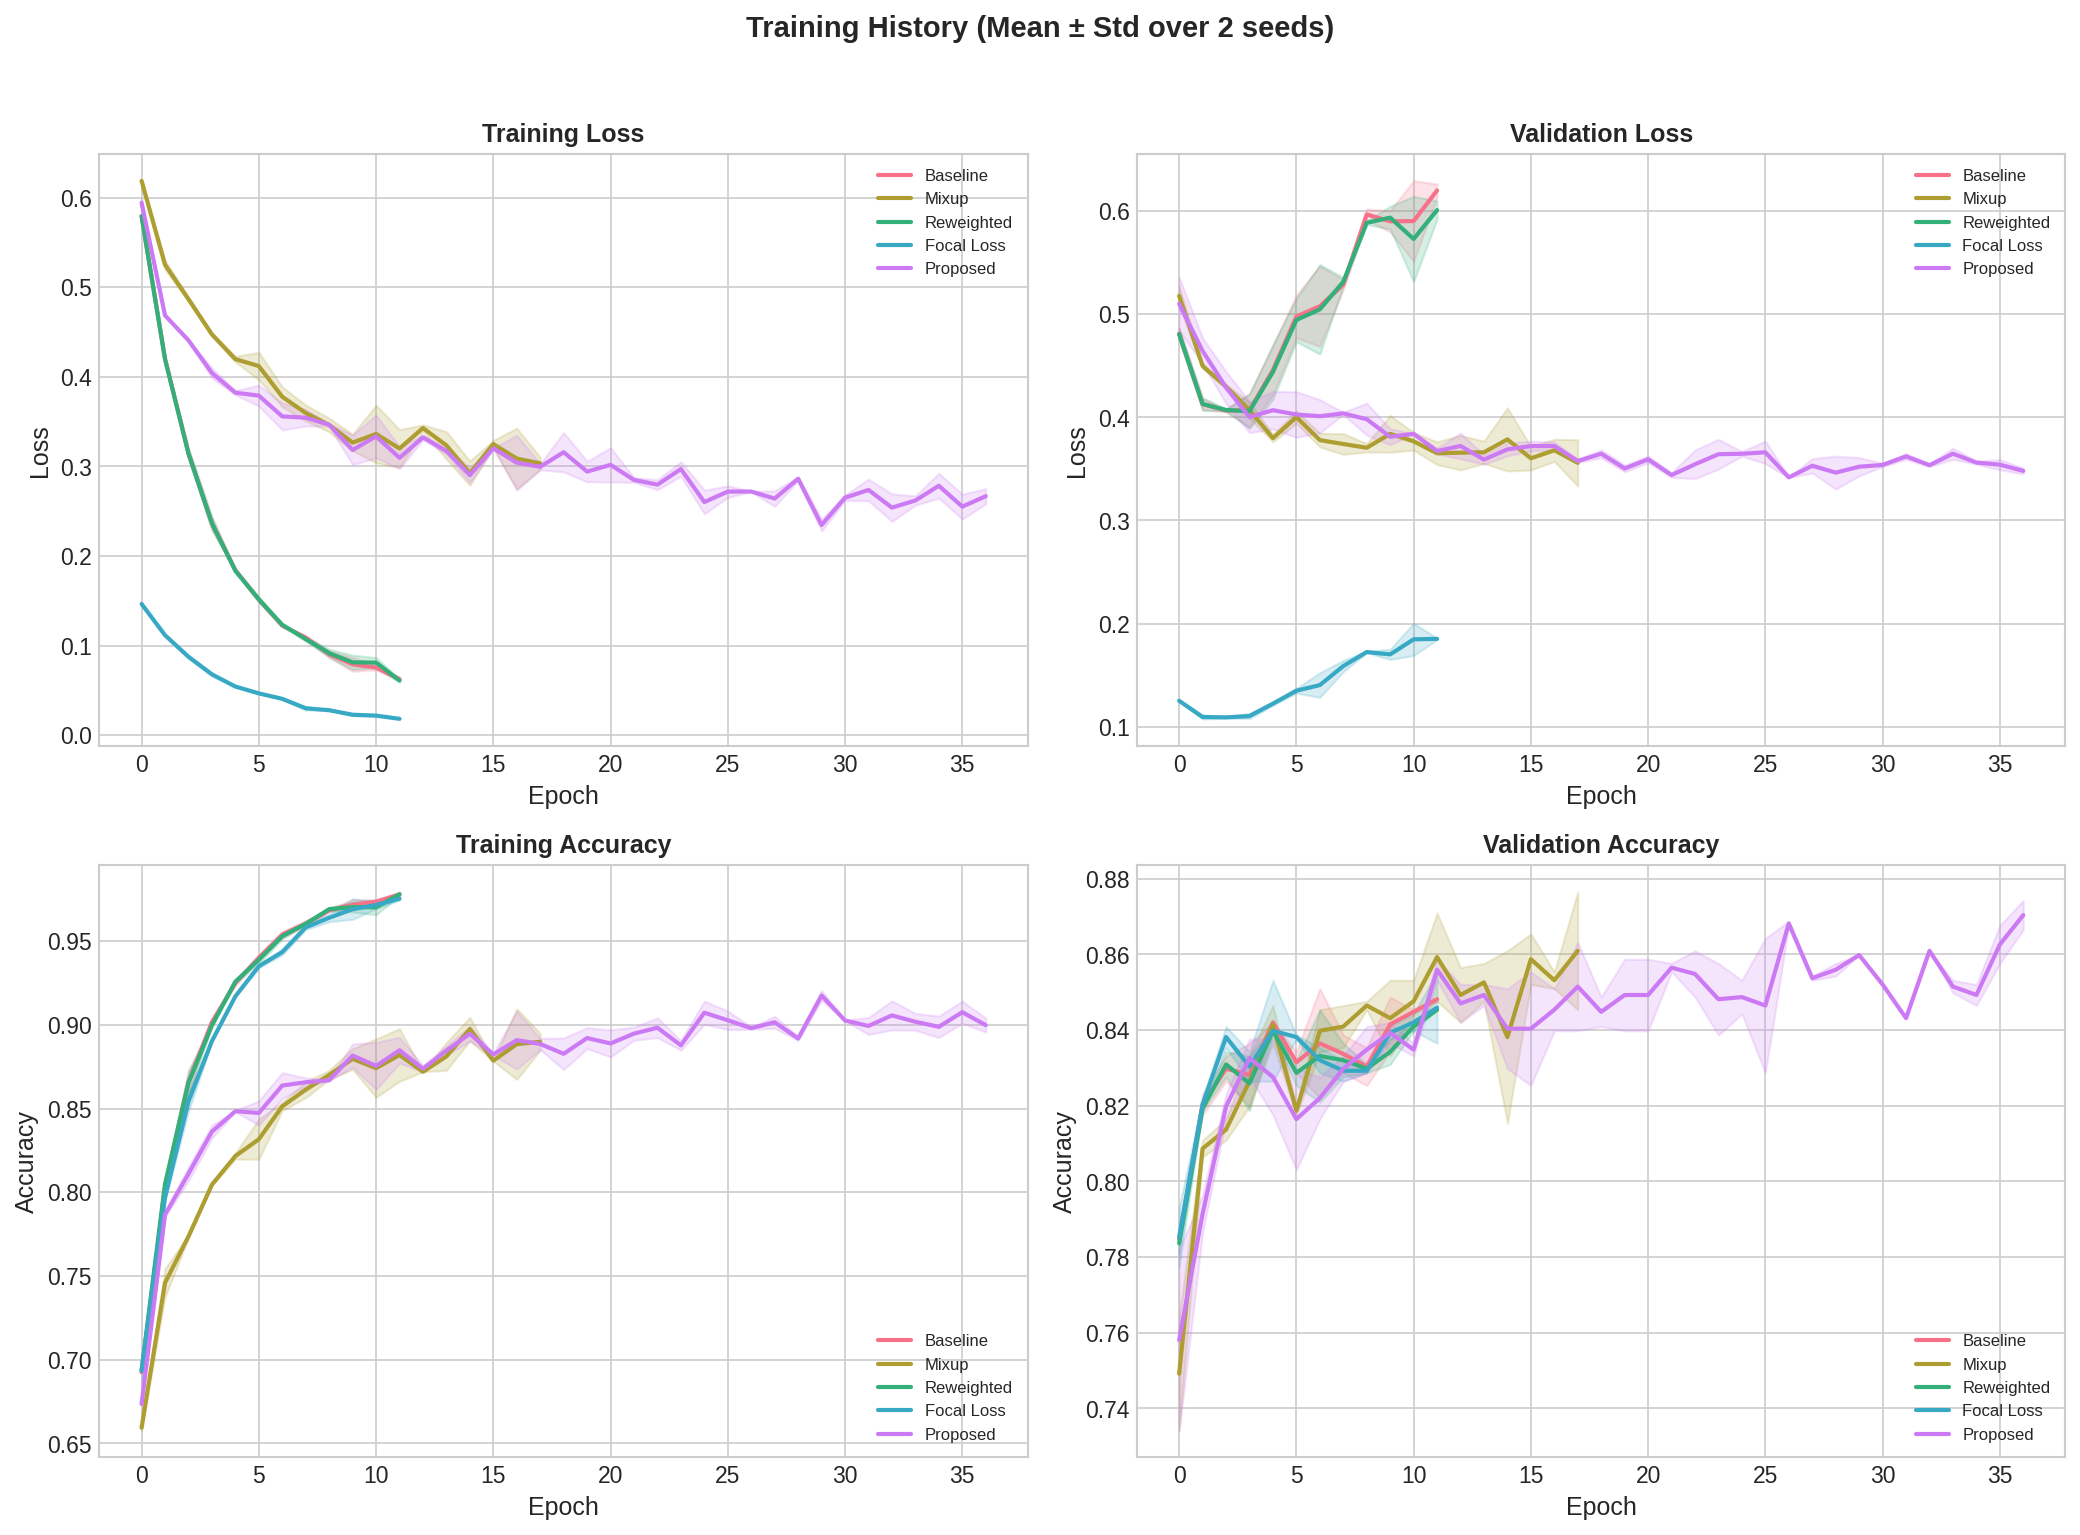

Saved: /content/drive/MyDrive/thesis/results/figures_multiseed/training_histories_multiseed.png


In [10]:
# Average training histories across seeds
def average_histories(histories_dict):
    """Average training histories across seeds."""
    if not histories_dict:
        return None

    # Find minimum length (some might have stopped earlier)
    min_len = min(len(h) for h in histories_dict.values())

    # Stack and average
    result = {}
    for col in ['train_loss', 'val_loss', 'train_acc', 'val_acc']:
        values = np.array([h[col].values[:min_len] for h in histories_dict.values()])
        result[col] = values.mean(axis=0)
        result[f'{col}_std'] = values.std(axis=0)
    result['epoch'] = np.arange(min_len)

    return pd.DataFrame(result)

# Average histories for each model
avg_histories = {}
for model in MODELS:
    if all_histories[model]:
        avg_histories[model] = average_histories(all_histories[model])

if avg_histories:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    colors = sns.color_palette('husl', len(avg_histories))

    for i, (model, history) in enumerate(avg_histories.items()):
        display_name = MODEL_DISPLAY_NAMES[model]
        epochs = history['epoch']

        # Training Loss with std shading
        ax = axes[0, 0]
        ax.plot(epochs, history['train_loss'], label=display_name, color=colors[i], linewidth=2)
        ax.fill_between(epochs,
                       history['train_loss'] - history['train_loss_std'],
                       history['train_loss'] + history['train_loss_std'],
                       color=colors[i], alpha=0.2)

        # Validation Loss
        ax = axes[0, 1]
        ax.plot(epochs, history['val_loss'], label=display_name, color=colors[i], linewidth=2)
        ax.fill_between(epochs,
                       history['val_loss'] - history['val_loss_std'],
                       history['val_loss'] + history['val_loss_std'],
                       color=colors[i], alpha=0.2)

        # Training Accuracy
        ax = axes[1, 0]
        ax.plot(epochs, history['train_acc'], label=display_name, color=colors[i], linewidth=2)
        ax.fill_between(epochs,
                       history['train_acc'] - history['train_acc_std'],
                       history['train_acc'] + history['train_acc_std'],
                       color=colors[i], alpha=0.2)

        # Validation Accuracy
        ax = axes[1, 1]
        ax.plot(epochs, history['val_acc'], label=display_name, color=colors[i], linewidth=2)
        ax.fill_between(epochs,
                       history['val_acc'] - history['val_acc_std'],
                       history['val_acc'] + history['val_acc_std'],
                       color=colors[i], alpha=0.2)

    axes[0, 0].set_title('Training Loss', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend(loc='upper right', fontsize=8)

    axes[0, 1].set_title('Validation Loss', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend(loc='upper right', fontsize=8)

    axes[1, 0].set_title('Training Accuracy', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend(loc='lower right', fontsize=8)

    axes[1, 1].set_title('Validation Accuracy', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].legend(loc='lower right', fontsize=8)

    plt.suptitle('Training History (Mean ± Std over 2 seeds)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'training_histories_multiseed.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {FIGURES_DIR / 'training_histories_multiseed.png'}")
else:
    print("No training histories available.")

## 10. Figure 6: Radar Chart

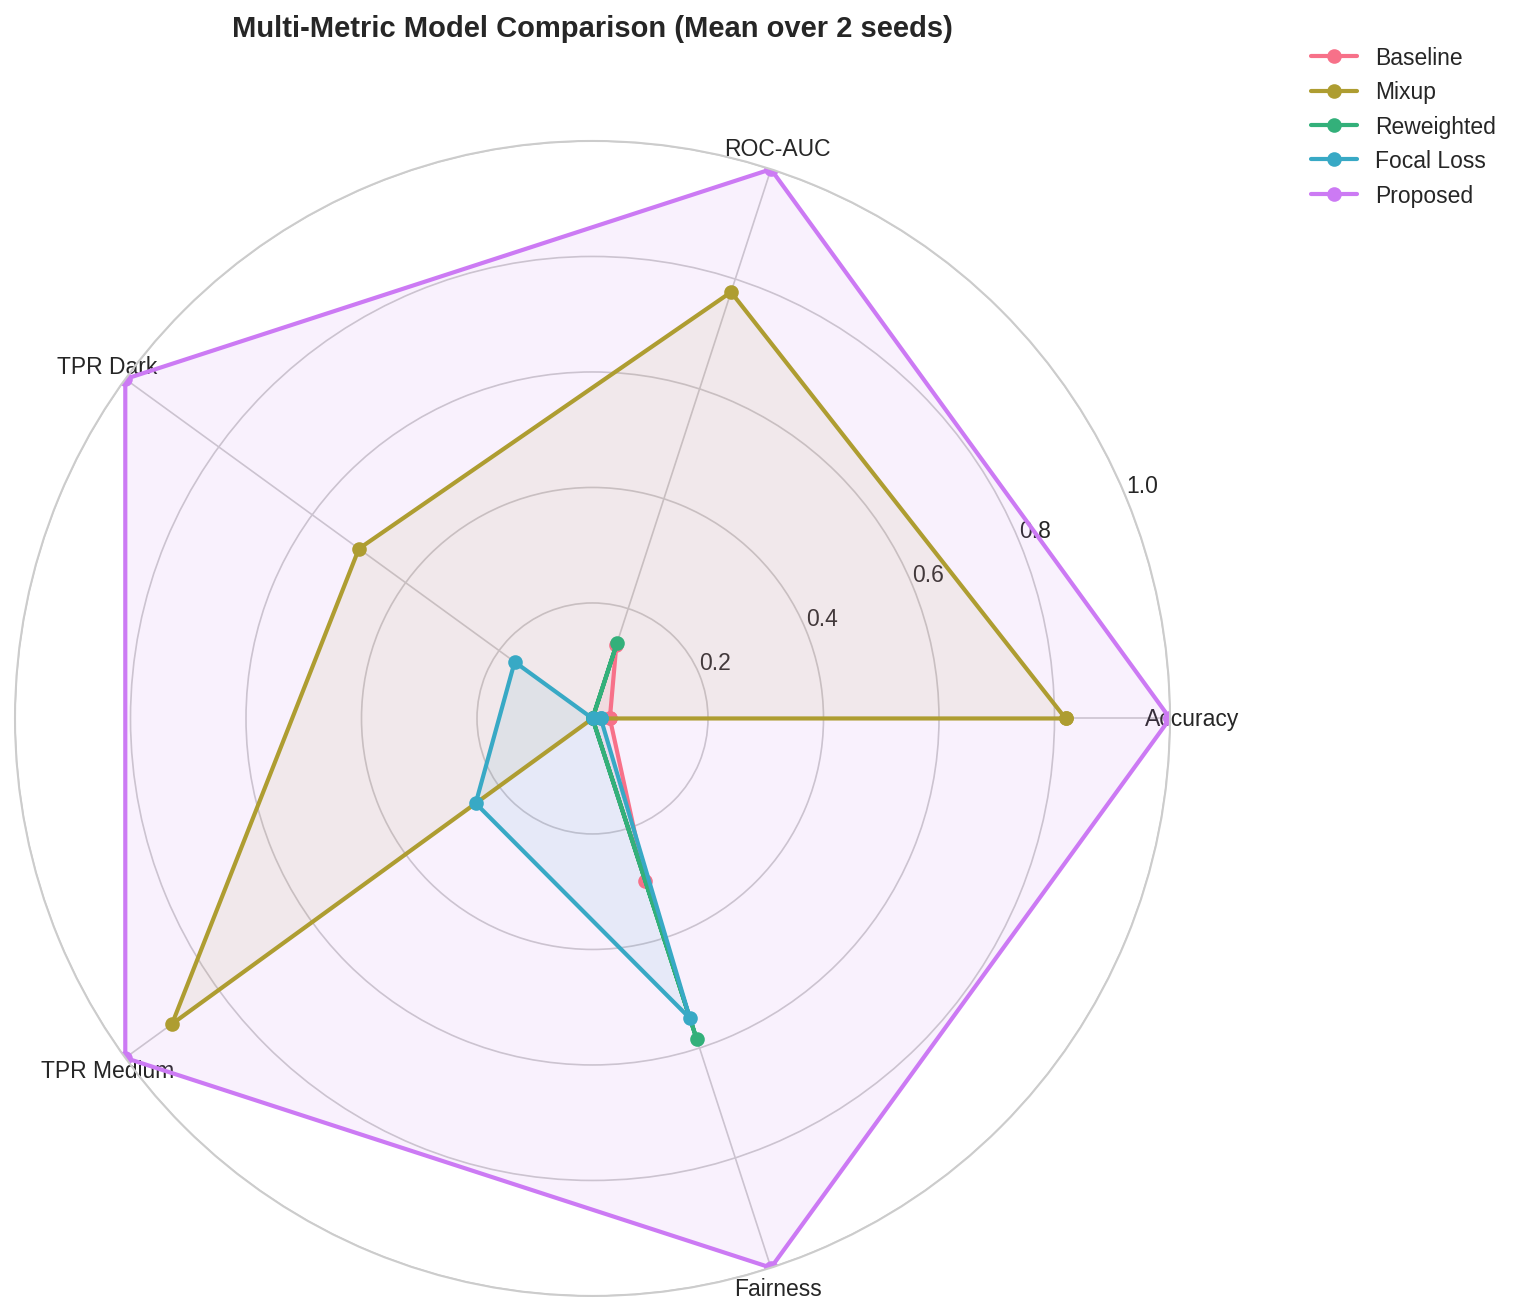

Saved: /content/drive/MyDrive/thesis/results/figures_multiseed/radar_comparison_multiseed.png


In [11]:
def create_radar_chart(df, title="Model Comparison"):
    """Create a radar chart comparing models across multiple metrics."""
    # Select metrics for radar (normalize fairness gaps so higher is better)
    metrics = {
        'Accuracy': df['Balanced Accuracy'],
        'ROC-AUC': df['ROC-AUC'],
        'TPR Dark': df['TPR Dark'],
        'TPR Medium': df['TPR Medium'],
        'Fairness': 1 - df['EO Gap'],  # Invert so higher is better
    }

    # Normalize to 0-1 scale
    radar_df = pd.DataFrame(metrics)
    radar_df = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())

    # Number of variables
    categories = list(radar_df.columns)
    N = len(categories)

    # Angle for each category
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # Complete the loop

    # Plot
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

    colors = sns.color_palette('husl', len(radar_df))

    for i, (model_name, row) in enumerate(radar_df.iterrows()):
        values = row.values.flatten().tolist()
        values += values[:1]  # Complete the loop

        ax.plot(angles, values, 'o-', linewidth=2, label=model_name, color=colors[i])
        ax.fill(angles, values, alpha=0.1, color=colors[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_ylim(0, 1)

    plt.title(title, size=14, fontweight='bold', y=1.08)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    return fig, ax

fig, ax = create_radar_chart(plot_df, "Multi-Metric Model Comparison (Mean over 2 seeds)")
plt.savefig(FIGURES_DIR / 'radar_comparison_multiseed.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'radar_comparison_multiseed.png'}")

## 11. Summary Statistics

In [12]:
print("=" * 80)
print("SUMMARY: BEST MODELS BY METRIC (Mean over 2 seeds)")
print("=" * 80)

# Best accuracy
best_acc_model = plot_df['Balanced Accuracy'].idxmax()
best_acc_value = plot_df['Balanced Accuracy'].max()
best_acc_std = plot_df.loc[best_acc_model, 'Balanced Accuracy Std']
print(f"\nBest Balanced Accuracy: {best_acc_model} ({best_acc_value:.4f} ± {best_acc_std:.4f})")

# Best ROC-AUC
best_auc_model = plot_df['ROC-AUC'].idxmax()
best_auc_value = plot_df['ROC-AUC'].max()
best_auc_std = plot_df.loc[best_auc_model, 'ROC-AUC Std']
print(f"Best ROC-AUC: {best_auc_model} ({best_auc_value:.4f} ± {best_auc_std:.4f})")

# Best fairness (lowest EO Gap)
best_fair_model = plot_df['EO Gap'].idxmin()
best_fair_value = plot_df['EO Gap'].min()
best_fair_std = plot_df.loc[best_fair_model, 'EO Gap Std']
print(f"Best Fairness (EO Gap): {best_fair_model} ({best_fair_value:.4f} ± {best_fair_std:.4f})")

# Best Dark Skin TPR
best_dark_model = plot_df['TPR Dark'].idxmax()
best_dark_value = plot_df['TPR Dark'].max()
best_dark_std = plot_df.loc[best_dark_model, 'TPR Dark Std']
print(f"Best Dark Skin TPR: {best_dark_model} ({best_dark_value:.4f} ± {best_dark_std:.4f})")

# Key improvements
print("\n" + "=" * 80)
print("KEY FINDINGS: PROPOSED VS BASELINE")
print("=" * 80)

if 'Proposed' in plot_df.index and 'Baseline' in plot_df.index:
    baseline = plot_df.loc['Baseline']
    proposed = plot_df.loc['Proposed']

    print(f"\nBalanced Accuracy:")
    print(f"  Baseline: {baseline['Balanced Accuracy']:.4f} ± {baseline['Balanced Accuracy Std']:.4f}")
    print(f"  Proposed: {proposed['Balanced Accuracy']:.4f} ± {proposed['Balanced Accuracy Std']:.4f}")
    print(f"  Improvement: {(proposed['Balanced Accuracy'] - baseline['Balanced Accuracy']) * 100:+.2f}%")

    print(f"\nEqual Opportunity Gap:")
    print(f"  Baseline: {baseline['EO Gap']:.4f} ± {baseline['EO Gap Std']:.4f}")
    print(f"  Proposed: {proposed['EO Gap']:.4f} ± {proposed['EO Gap Std']:.4f}")
    print(f"  Reduction: {(baseline['EO Gap'] - proposed['EO Gap']) * 100:+.2f}% gap reduction")

    print(f"\nDark Skin TPR:")
    print(f"  Baseline: {baseline['TPR Dark']:.4f} ± {baseline['TPR Dark Std']:.4f}")
    print(f"  Proposed: {proposed['TPR Dark']:.4f} ± {proposed['TPR Dark Std']:.4f}")
    print(f"  Improvement: {(proposed['TPR Dark'] - baseline['TPR Dark']) * 100:+.2f}%")

SUMMARY: BEST MODELS BY METRIC (Mean over 2 seeds)

Best Balanced Accuracy: Proposed (0.8627 ± 0.0050)
Best ROC-AUC: Proposed (0.9302 ± 0.0039)
Best Fairness (EO Gap): Proposed (0.0714 ± 0.0025)
Best Dark Skin TPR: Proposed (0.7805 ± 0.0000)

KEY FINDINGS: PROPOSED VS BASELINE

Balanced Accuracy:
  Baseline: 0.8272 ± 0.0094
  Proposed: 0.8627 ± 0.0050
  Improvement: +3.55%

Equal Opportunity Gap:
  Baseline: 0.0918 ± 0.0049
  Proposed: 0.0714 ± 0.0025
  Reduction: +2.05% gap reduction

Dark Skin TPR:
  Baseline: 0.7073 ± 0.0244
  Proposed: 0.7805 ± 0.0000
  Improvement: +7.32%


## 12. Save All Results

In [13]:
# Helper for JSON serialization
def convert_to_serializable(obj):
    if isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(i) for i in obj]
    return obj

# 1. Save aggregated results JSON
json_path = RESULTS_DIR / 'aggregated_results_2seeds.json'
with open(json_path, 'w') as f:
    json.dump(convert_to_serializable(aggregated), f, indent=2)
print(f"Saved: {json_path}")

# 2. Save display-ready comparison table
display_path = RESULTS_DIR / 'multi_seed_comparison.csv'
display_df.to_csv(display_path, index=False)
print(f"Saved: {display_path}")

# 3. Save full numeric results for further analysis
numeric_path = RESULTS_DIR / 'multi_seed_results_numeric.csv'
plot_df.to_csv(numeric_path)
print(f"Saved: {numeric_path}")

# 4. Save per-seed results for transparency
per_seed_rows = []
for model in MODELS:
    for seed in SEEDS:
        if seed in all_results[model]:
            r = all_results[model][seed]
            per_seed_rows.append({
                'model': model,
                'seed': seed,
                'accuracy': r['overall']['accuracy'],
                'balanced_accuracy': r['overall']['balanced_accuracy'],
                'roc_auc': r['overall'].get('roc_auc'),
                'f1_macro': r['overall']['f1_macro'],
                'equal_opportunity_gap': r['fairness']['equal_opportunity_gap'],
                'equalized_odds_gap': r['fairness']['equalized_odds_gap'],
                'f1_gap': r['fairness']['f1_gap'],
                'tpr_light': r['fairness']['tpr_per_group'].get('Light'),
                'tpr_medium': r['fairness']['tpr_per_group'].get('Medium'),
                'tpr_dark': r['fairness']['tpr_per_group'].get('Dark'),
            })

per_seed_df = pd.DataFrame(per_seed_rows)
per_seed_path = RESULTS_DIR / 'fitzpatrick_results_per_seed.csv'
per_seed_df.to_csv(per_seed_path, index=False)
print(f"Saved: {per_seed_path}")

print("\n" + "=" * 60)
print("ALL RESULTS SAVED")
print("=" * 60)

Saved: /content/drive/MyDrive/thesis/results/aggregated_results_2seeds.json
Saved: /content/drive/MyDrive/thesis/results/multi_seed_comparison.csv
Saved: /content/drive/MyDrive/thesis/results/multi_seed_results_numeric.csv
Saved: /content/drive/MyDrive/thesis/results/fitzpatrick_results_per_seed.csv

ALL RESULTS SAVED


## 13. Load and Display DDI Results (if available)

In [14]:
# Check for DDI multi-seed results
ddi_agg_path = RESULTS_DIR / 'ddi_evaluation' / 'ddi_evaluation_aggregated.csv'
ddi_comparison_path = RESULTS_DIR / 'ddi_evaluation' / 'fitz_vs_ddi_comparison.csv'

if ddi_agg_path.exists():
    print("DDI Multi-Seed Evaluation Results Found!")
    print("=" * 60)

    ddi_results = pd.read_csv(ddi_agg_path)
    display(ddi_results)

    if ddi_comparison_path.exists():
        print("\nFitzpatrick17k vs DDI Comparison:")
        print("=" * 60)
        comparison = pd.read_csv(ddi_comparison_path)
        display(comparison)
else:
    print("DDI multi-seed results not found.")
    print("Run ddi_evaluation_multiseed.ipynb to generate them.")

DDI Multi-Seed Evaluation Results Found!


,model,n_seeds,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,eo_gap_mean,eo_gap_std,tpr_dark_mean,tpr_dark_std
0,baseline,2,0.634675,0.012531,0.664116,0.011051,0.349065,0.009779,0.395833,0.020833
1,mixup,2,0.611066,0.000093,0.642431,0.004353,0.280348,0.119312,0.479167,0.062500
2,reweighted,2,0.639661,0.011669,0.666564,0.010870,0.349065,0.009779,0.395833,0.020833
3,focalloss,2,0.615527,0.019494,0.646645,0.015030,0.410502,0.030400,0.385417,0.010417
4,proposed,2,0.606080,0.007985,0.638102,0.012009,0.298297,0.101788,0.437500,0.041667



Fitzpatrick17k vs DDI Comparison:


,Model,Fitz Bal Acc,DDI Bal Acc,Accuracy Drop,Fitz EO Gap,DDI EO Gap
0,Baseline,0.8272,0.6347,19.2%,0.0918,0.3491
1,Mixup,0.8561,0.6111,24.5%,0.1005,0.2803
2,Reweighted,0.8261,0.6397,18.6%,0.0835,0.3491
3,Focalloss,0.8266,0.6155,21.1%,0.0846,0.4105
4,Proposed,0.8627,0.6061,25.7%,0.0714,0.2983


Generating DDI specific charts...


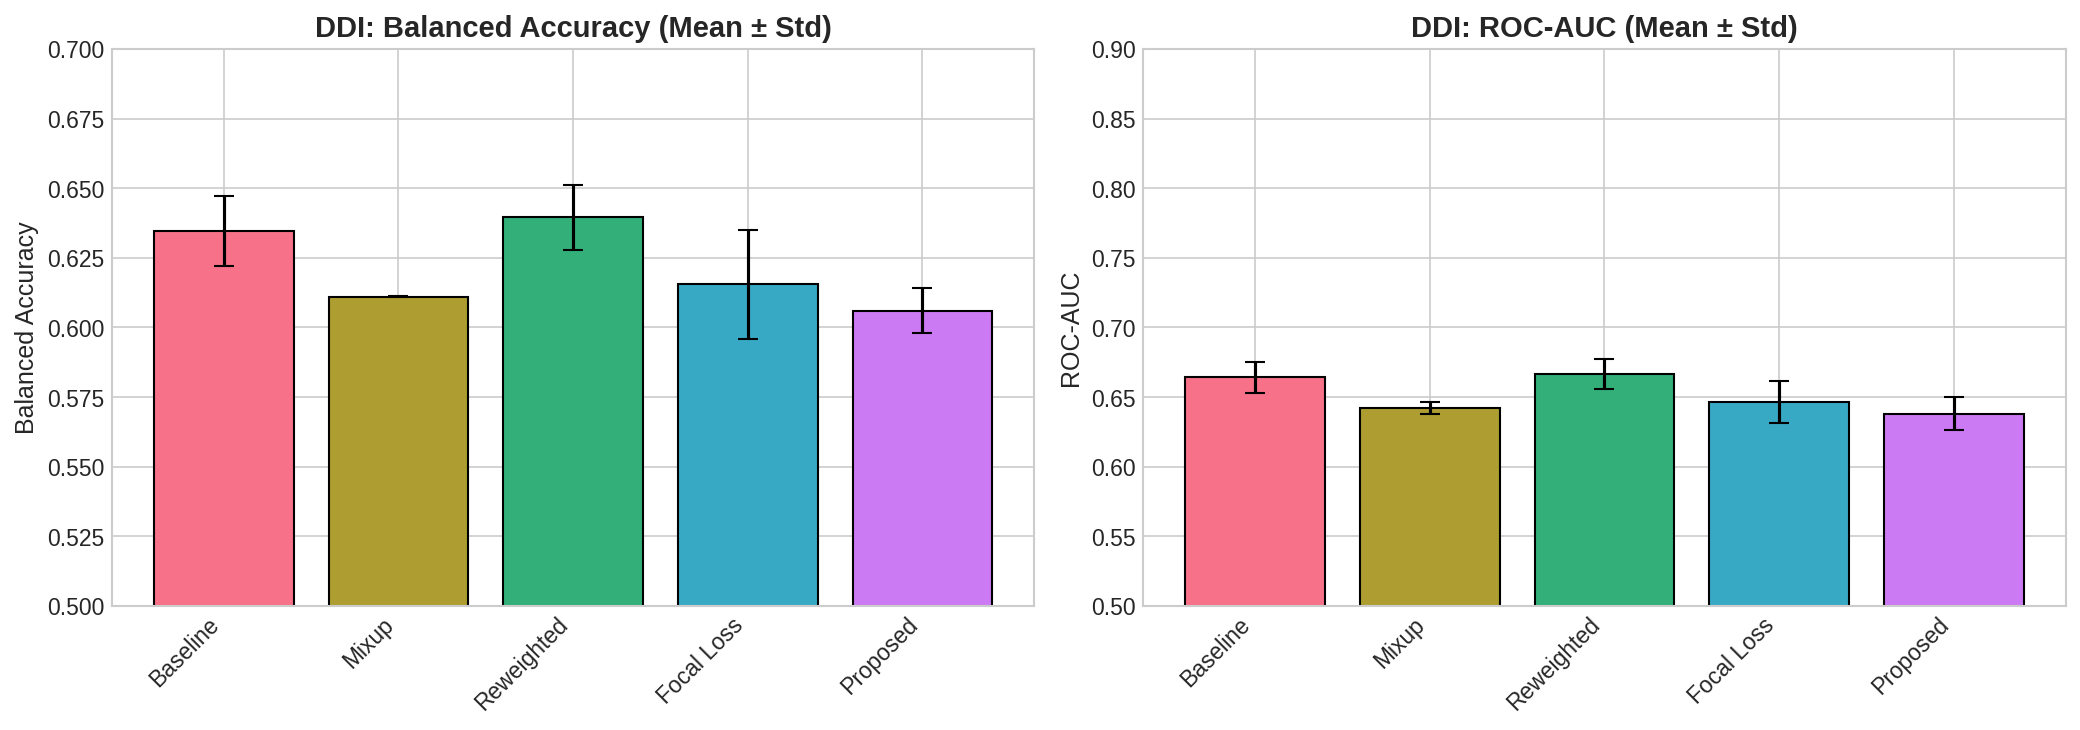

Saved: /content/drive/MyDrive/thesis/results/figures_multiseed/ddi_performance_multiseed.png


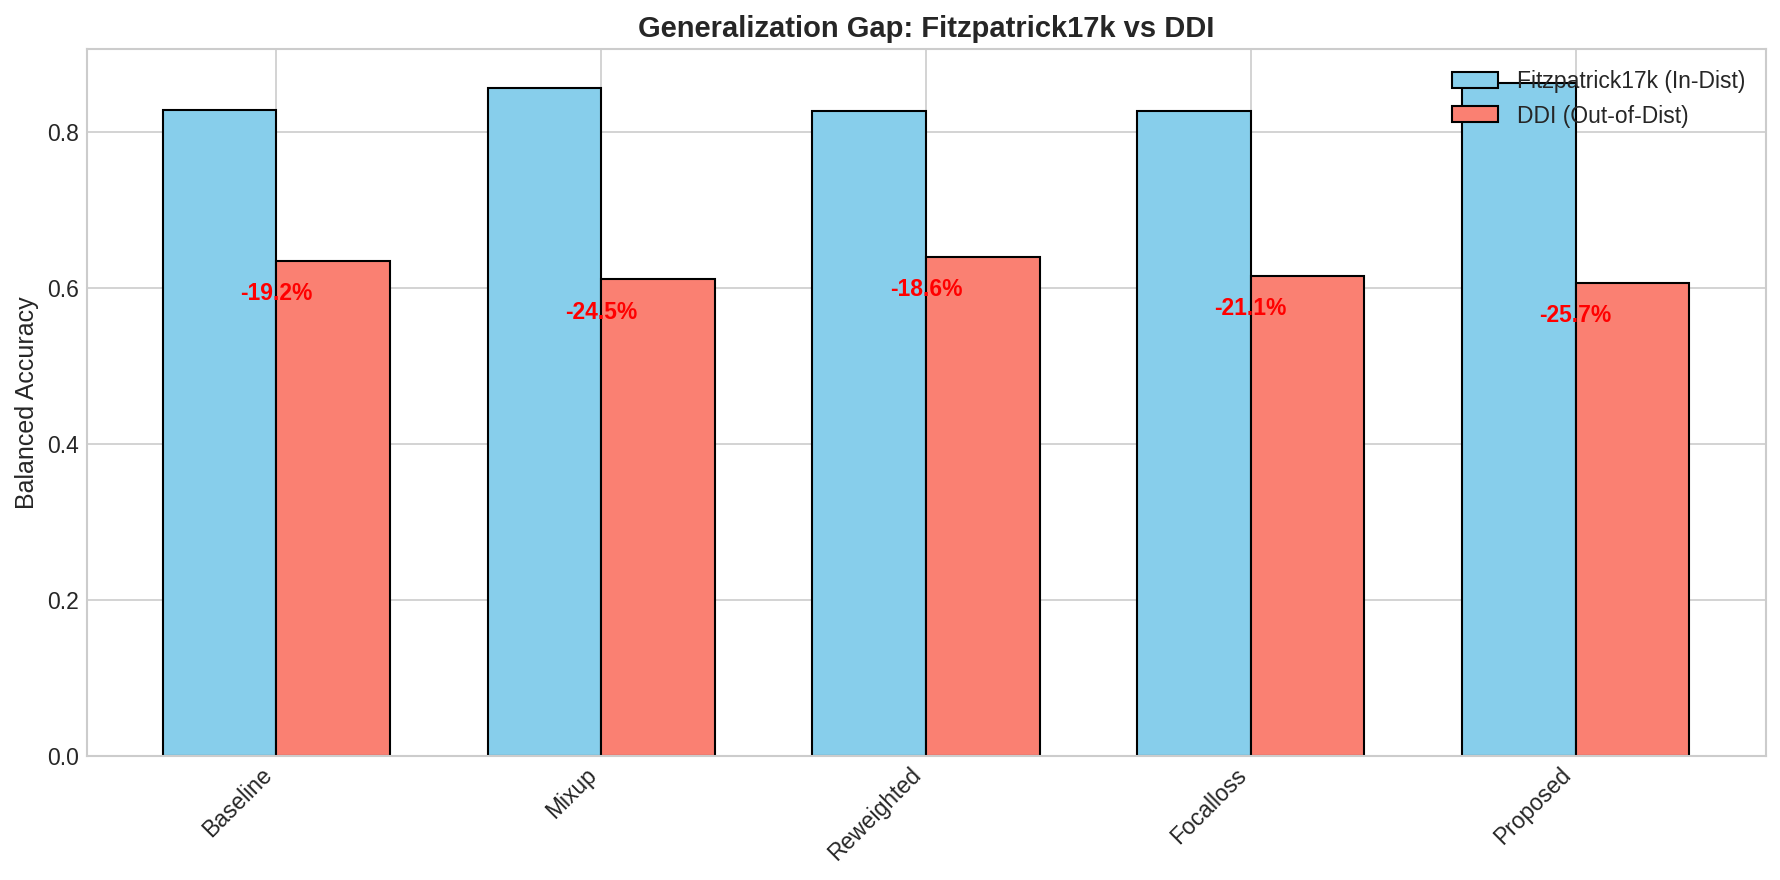

Saved: /content/drive/MyDrive/thesis/results/figures_multiseed/fitz_vs_ddi_comparison.png


In [15]:
if 'ddi_results' in locals() and ddi_results is not None:
    print("Generating DDI specific charts...")

    # Prepare DDI data for plotting
    ddi_plot_df = ddi_results.copy()
    ddi_plot_df['Display Name'] = ddi_plot_df['model'].map(MODEL_DISPLAY_NAMES)
    ddi_plot_df = ddi_plot_df.set_index('Display Name')

    # Define colors
    colors = sns.color_palette('husl', len(ddi_plot_df))

    # --- Figure 7: DDI Overall Performance ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Balanced Accuracy
    ax1 = axes[0]
    x = np.arange(len(ddi_plot_df))
    ax1.bar(x, ddi_plot_df['balanced_accuracy_mean'],
            yerr=ddi_plot_df['balanced_accuracy_std'],
            color=colors, edgecolor='black', capsize=5)
    ax1.set_title('DDI: Balanced Accuracy (Mean ± Std)', fontsize=14, fontweight='bold')
    ax1.set_ylim(0.5, 0.7)  # Adjusted for lower DDI scores
    ax1.set_xticks(x)
    ax1.set_xticklabels(ddi_plot_df.index, rotation=45, ha='right')
    ax1.set_ylabel('Balanced Accuracy')

    # ROC-AUC
    ax2 = axes[1]
    ax2.bar(x, ddi_plot_df['roc_auc_mean'],
            yerr=ddi_plot_df['roc_auc_std'],
            color=colors, edgecolor='black', capsize=5)
    ax2.set_title('DDI: ROC-AUC (Mean ± Std)', fontsize=14, fontweight='bold')
    ax2.set_ylim(0.5, 0.9)
    ax2.set_xticks(x)
    ax2.set_xticklabels(ddi_plot_df.index, rotation=45, ha='right')
    ax2.set_ylabel('ROC-AUC')

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'ddi_performance_multiseed.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {FIGURES_DIR / 'ddi_performance_multiseed.png'}")

    # --- Figure 8: DDI Fairness (EO Gap) ---
    if 'equal_opportunity_gap_mean' in ddi_plot_df.columns:
        fig, ax = plt.subplots(figsize=(10, 6))

        ax.bar(x, ddi_plot_df['equal_opportunity_gap_mean'],
               yerr=ddi_plot_df['equal_opportunity_gap_std'],
               color='#FF6B6B', edgecolor='black', capsize=5)

        ax.set_title('DDI: Equal Opportunity Gap (Mean ± Std)', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(ddi_plot_df.index, rotation=45, ha='right')
        ax.set_ylabel('Gap (Lower is Better)')

        # Add value labels
        for i, (val, std) in enumerate(zip(ddi_plot_df['equal_opportunity_gap_mean'],
                                          ddi_plot_df['equal_opportunity_gap_std'])):
            ax.text(i, val + std + 0.01, f'{val:.3f}', ha='center', va='bottom')

        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'ddi_fairness_multiseed.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Saved: {FIGURES_DIR / 'ddi_fairness_multiseed.png'}")

    # --- Figure 9: Fitz vs DDI Comparison (Shift) ---
    if 'comparison' in locals() and comparison is not None:
        fig, ax = plt.subplots(figsize=(12, 6))

        comp_df = comparison.copy()
        # Ensure Model names are mapped if needed (comparison df usually has raw names or mapped already)
        # Assuming 'Model' column in comparison matches display names or close to it

        x = np.arange(len(comp_df))
        width = 0.35

        rects1 = ax.bar(x - width/2, comp_df['Fitz Bal Acc'], width, label='Fitzpatrick17k (In-Dist)', color='skyblue', edgecolor='black')
        rects2 = ax.bar(x + width/2, comp_df['DDI Bal Acc'], width, label='DDI (Out-of-Dist)', color='salmon', edgecolor='black')

        ax.set_ylabel('Balanced Accuracy')
        ax.set_title('Generalization Gap: Fitzpatrick17k vs DDI', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(comp_df['Model'], rotation=45, ha='right')
        ax.legend()

        # Add drop percentage labels
        for i, row in comp_df.iterrows():
            drop = row['Accuracy Drop'] # Assuming string "XX%"
            ax.text(i, row['DDI Bal Acc'] - 0.05, f"-{drop}", ha='center', color='red', fontweight='bold')

        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'fitz_vs_ddi_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Saved: {FIGURES_DIR / 'fitz_vs_ddi_comparison.png'}")

else:
    print("DDI results not available to plot.")

## Summary

This notebook has generated the following outputs:

**Figures (with error bars):**
1. `performance_comparison_multiseed.png` - Balanced Accuracy & ROC-AUC
2. `fairness_gaps_multiseed.png` - EO Gap, Equalized Odds Gap, F1 Gap
3. `per_group_tpr_multiseed.png` - Per-group sensitivity
4. `accuracy_fairness_tradeoff_multiseed.png` - Scatter plots
5. `training_histories_multiseed.png` - Training curves with std shading
6. `radar_comparison_multiseed.png` - Multi-metric radar chart

**Data Files:**
1. `aggregated_results_2seeds.json` - Full aggregated metrics
2. `multi_seed_comparison.csv` - Display-ready table (mean ± std)
3. `multi_seed_results_numeric.csv` - Numeric values for plotting
4. `fitzpatrick_results_per_seed.csv` - Individual seed results

All figures saved to: `results/figures_multiseed/`